NumPy简介2 - 形状操作、索引切片与内存模型
==============


# 开头

- 上期：数组创建、逐元素计算、广播机制
- 本期：形状操作、索引与切片、内存模型


In [ ]:
# 辅助函数：读取、展示图片、视频
import numpy as np
from PIL import Image
from IPython.display import display, Image as IPythonImage
import imageio
import io
try:
    from moviepy.editor import VideoFileClip
except ModuleNotFoundError:
    from moviepy import VideoFileClip

# 下载素材
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/Clark.jpg
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/ClarkFalling.mp4


def read_image(path="downloads/Clark.jpg"):
    img = Image.open(path)
    return np.asarray(img).copy()


def display_image(img):
    display(Image.fromarray(img))


def read_video(video_path="downloads/ClarkFalling.mp4"):
    with VideoFileClip(str(video_path)) as clip:
        video = np.stack([frame for frame in clip.iter_frames()], axis=0)
    return video


def display_video_as_gif(video, fps=20, loop=0):
    buf = io.BytesIO()
    imageio.mimsave(buf, video, format="gif", fps=fps, loop=loop)
    display(IPythonImage(data=buf.getvalue(), format="gif"))


# 第五章：形状操作


## 5.1 Reshape

In [ ]:
x = np.arange(12)
print(x)
print(f"{x.shape=}")

In [ ]:
x2d = x.reshape(3, 4)
print(x2d)
print(f"{x2d.shape=}")

In [ ]:
x3d = x.reshape(-1, 2, 3)  # 可以有一维是-1，自动推断此维长度。
print(x3d)
print(f"{x3d.shape=}")

**共享内存?**

In [ ]:
x2d[0, 0] = 666
x3d[1, 1, 1] = 888
print(x)

## 5.2 增加一个（长度为1的）维度
- `expand_dims` / `newaxis(None)`：增加维度

In [ ]:
# 准备: x 和 y 差1个维度
x = np.zeros([3, 4, 5])
y = np.ones([4, 5])

print(f"{x.shape = }")
print(f"{y.shape = }")

In [ ]:
# 尝试1: reshape
y1 = y.reshape([1, 4, 5])
print(f"{y1.shape = }")

z1 = x + y1
print(f"{z1.shape = }")

In [ ]:
# 尝试2: expand_dims
y2 = np.expand_dims(y, axis=0)
print(f"{y2.shape = }")

z2 = x + y2
print(f"{z2.shape = }")

In [ ]:
# 尝试3: np.newaxis / None
y3 = y[np.newaxis, :]
y4 = y[None, :]
print(f"{y3.shape = }")
print(f"{y4.shape = }")

## 5.3 去掉一个（长度为1的）维度

In [ ]:
x = np.zeros([3, 4, 5])
y = np.ones([1, 3, 4, 5])
print(f"{x.shape = }")
print(f"{y.shape = }")

In [ ]:
y_squeezed = np.squeeze(y, axis=0)
z = x + y_squeezed

print(f"{y_squeezed.shape = }")
print(f"{z.shape          = }")

**小结：**

- `expand_dims` 和 `squeeze` 经常用于维度对齐，并配合 broadcasting 使用。
- 从效果上看，它们都可以用 `reshape` 实现；只是写法更简洁，相当于语法糖。


## 5.4 `ravel / flatten`：拍扁成 1 维


In [ ]:
x = np.random.rand(3, 4)
y = x.ravel()
z = x.flatten()

print(f"{x.shape=}")
print(f"{y.shape=}")
print(f"{z.shape=}")

In [ ]:
print(f"{np.shares_memory(x, y) = }")
print(f"{np.shares_memory(x, z) = }")

# 第六章：索引与切片


## 6.1 索引


In [ ]:
x = np.arange(12).reshape(3, 4)
print(x)

In [ ]:
print(x[0, 1])
print(x[2, 3])

In [ ]:
x[1, 2] = -100
print(x)

## 6.2 切片（slice）


### 6.2.1 一维切片


In [ ]:
v = np.arange(10)
print(v)

In [ ]:
a = 2
b = 6
print(v[a:b])              # 索引在[a, b)左闭右开区间的元素


In [ ]:
i = 3

print(v[:i])
print(v[0:i])              # 等价形式


In [ ]:
print(v[i:])
print(v[i:len(v)])         # 等价形式


In [ ]:
print(v[-2:])
print(v[len(v)-2:len(v)])  # 等价形式


In [ ]:
print(v[0:6:2])            # 在[0, 6)中，每隔2步取一个元素。


In [ ]:
print(v[5:0:-2])           # 步长为-2，逆序


### 6.2.2 二维数组切片


In [ ]:
x = np.arange(12).reshape(3, 4)
print(x)

In [ ]:
print(x[0])       # 第0行


In [ ]:
print(x[:, 1])    # 第1列


In [ ]:
print(x[1:, 2:])  # 第1行、第2列后的子矩阵


## 6.3 通过切片修改多个值


In [ ]:
# 读取图片:
img = read_image()
print(f"{img.shape=}, {img.dtype=}")
display_image(img)

In [ ]:
img[220:235, 420:455] = (255, 0, 0)  # 左眼区域设为红色
img[210:225, 495:520] = (0, 255, 0)  # 右眼区域设为绿色

display_image(img)

## 6.4 高维切片示例（N × H × W × 3）


In [ ]:
# 读取原视频:
video = read_video()
print(f"{video.shape=}, {video.dtype=}")
display_video_as_gif(video)

In [ ]:
# 空间切割:
cropped = video[:, 100:300, 100:300]
print(f"{cropped.shape=}")
display_video_as_gif(cropped)

In [ ]:
# 3倍速播放:
speed_up = video[::3]
print(f"{speed_up.shape=}")
display_video_as_gif(speed_up)

In [ ]:
# 倒序播放:
reversed = video[::-1]
print(f"{reversed.shape=}")
display_video_as_gif(reversed)

In [ ]:
# 取出某帧:
first_frame = video[0]
print(f"{first_frame.shape=}")
display_image(first_frame)

In [ ]:
# 黑白化 (R通道用于GB通道):
video[..., 1] = video[..., 0]
video[..., 2] = video[..., 0]
display_video_as_gif(video)

# 第七章：ndarray 的内存模型


## 7.1 ndarray 与 Python list 的区别


<!-- embedded-video-7.1 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.2 二维 ndarray 在内存中的存储方式


<!-- embedded-video-7.2 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.3 三维 ndarray


<!-- embedded-video-7.3 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.4 reshape：为什么通常不需要拷贝


<!-- embedded-video-7.4 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.5 slice 为什么会影响原数组


<!-- embedded-video-7.5 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.6 什么时候会真正发生copy?
- 显式调用了 copy()
- 操作后的数组，无法再用原来的内存布局来表示
  - 如 `transpose` + `reshape`

<!-- embedded-video-7.6 -->
<video controls muted playsinline width="960" src="..."></video>


## 7.7 工程经验: 是否发生了 copy?

- `reshape`、`slice` 这类简单操作，通常不会触发 copy。
- 转置等改变存储结构的操作，`reshape`后可能触发 copy。
- 不确定时，直接用 `np.shares_memory()` 判断。

In [ ]:
# 示例1:
x = np.arange(12).reshape(3, 4)
y = x[:, 1:3]   # slice，通常是 view

print(np.shares_memory(x, y))  # True

In [ ]:
# 示例2:
x = np.arange(12).reshape(3, 4)
y = x.T.reshape(-1)  # 这里通常会触发 copy

print(np.shares_memory(x, y))  # False

# 第八章：思考题

这张图片由 **52 张扑克牌** 组成，按 **4 行 × 13 列** 排布。
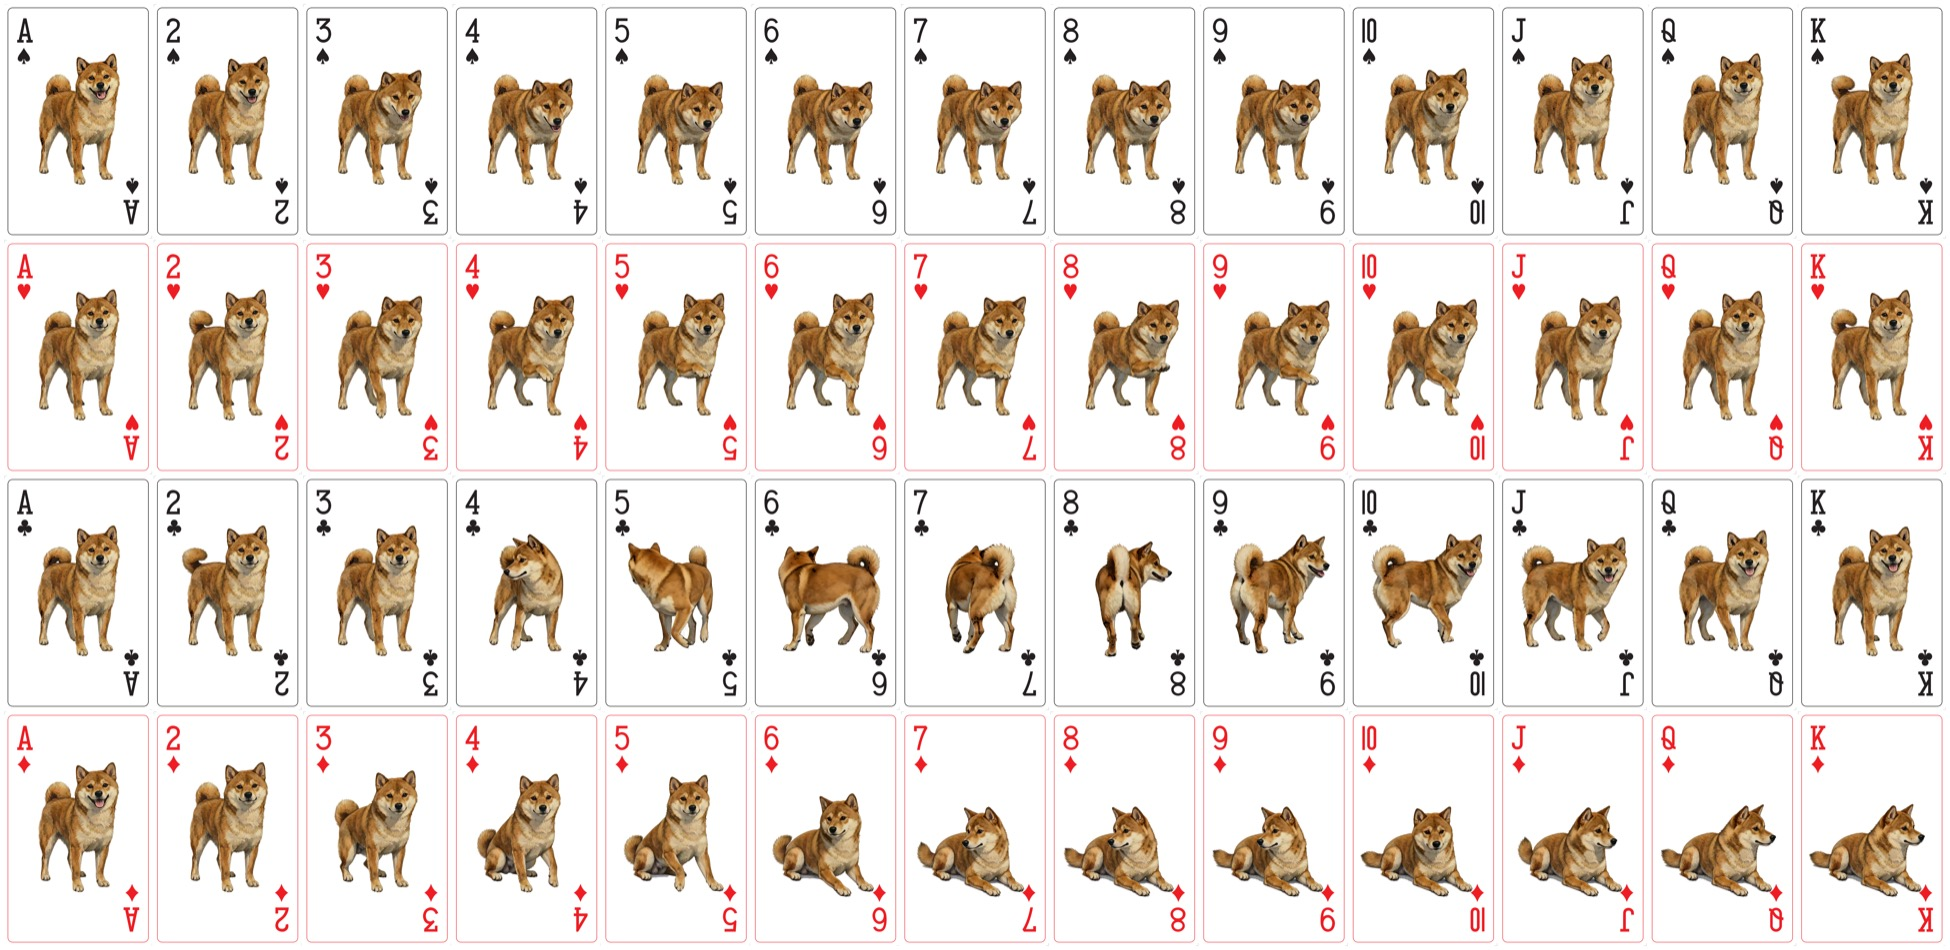


**问题：** 如何把这些扑克牌同时上下、左右颠倒？

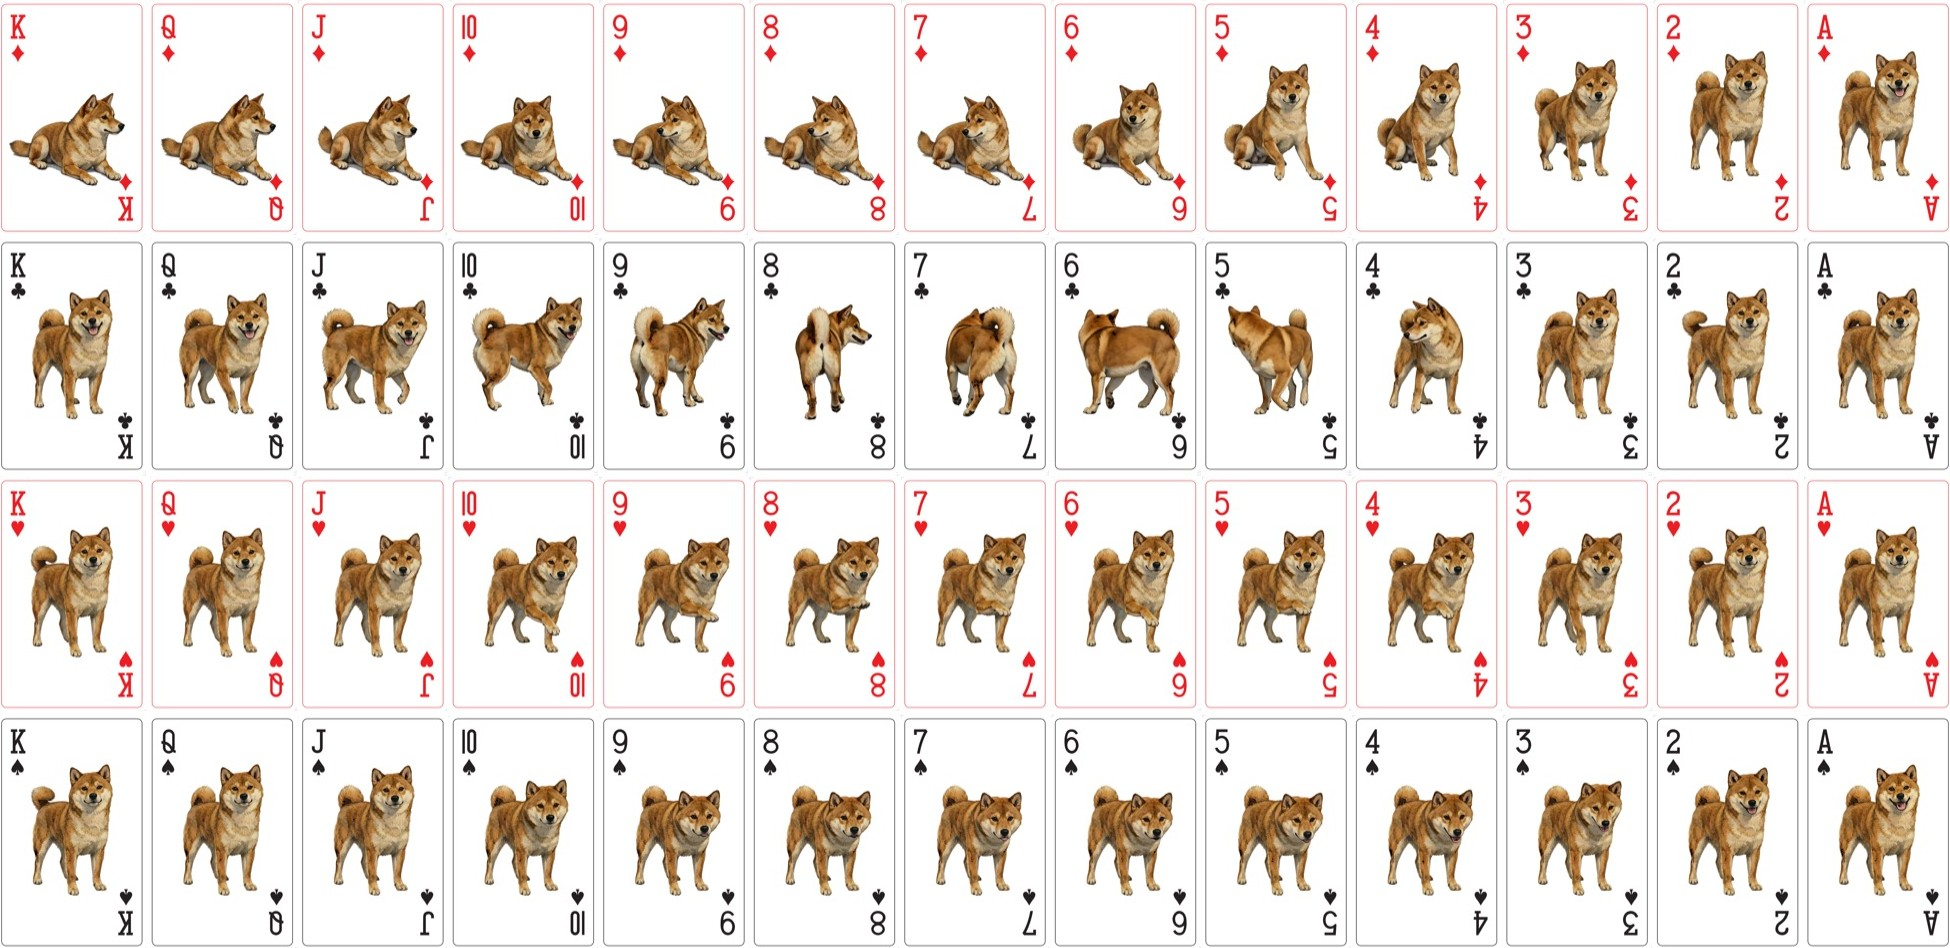

**提示:**
1. 不要逐像素处理。
2. 能否只用 `reshape` 和 `slicing`？